# Rice Disease are classified using CNN with Tensorflow


In [1]:
# import laibraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf

In [ ]:
data = pd.read_csv('D:/python_for_data_science/paddy_rice/resources/train.csv') 
data.head()

,image_id,label,variety,age
0,100330.jpg,bacterial_leaf_blight,ADT45,45
1,100365.jpg,bacterial_leaf_blight,ADT45,45
2,100382.jpg,bacterial_leaf_blight,ADT45,45
3,100632.jpg,bacterial_leaf_blight,ADT45,45
4,101918.jpg,bacterial_leaf_blight,ADT45,45


In [3]:
# check the shape of data 
data.shape


(10407, 4)

In [4]:
data['label'].unique().tolist()

['bacterial_leaf_blight',
 'bacterial_leaf_streak',
 'bacterial_panicle_blight',
 'blast',
 'brown_spot',
 'dead_heart',
 'downy_mildew',
 'hispa',
 'normal',
 'tungro']

In [5]:
data['variety'].unique().tolist()

['ADT45',
 'IR20',
 'KarnatakaPonni',
 'Onthanel',
 'Ponni',
 'Surya',
 'Zonal',
 'AndraPonni',
 'AtchayaPonni',
 'RR']

In [6]:
data['age'].describe()

count    10407.000000
mean        64.043624
std          8.958830
min         45.000000
25%         60.000000
50%         67.000000
75%         70.000000
max         82.000000
Name: age, dtype: float64

In [7]:
normal = data[data['label'] == 'normal']
normal = normal[normal['variety'] == 'ADT45']
five_normals = normal.image_id[:5].values
five_normals.tolist()

['100007.jpg', '100025.jpg', '100135.jpg', '100165.jpg', '100171.jpg']

In [8]:
normal = data[data['label'] == 'dead_heart']
normal = normal[normal['variety'] == 'ADT45']
five_deads = normal.image_id[:5].values
five_deads.tolist()

['101165.jpg', '102750.jpg', '108367.jpg', '109900.jpg', '100222.jpg']

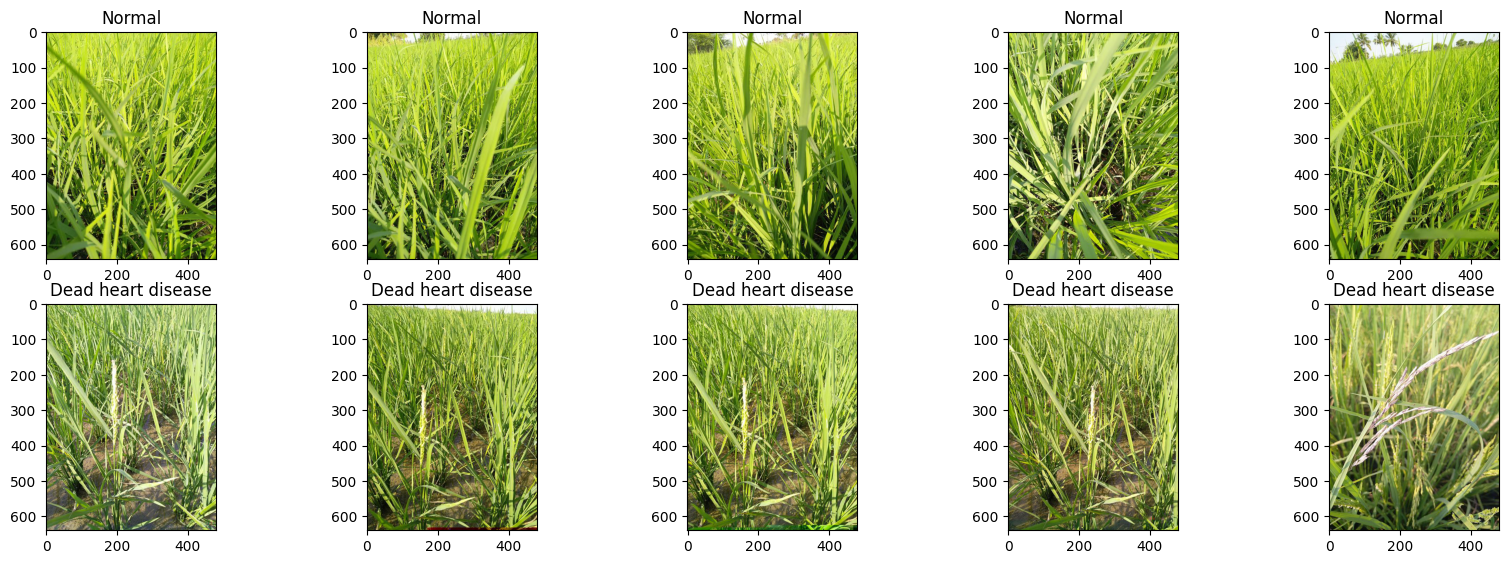

In [9]:
# plot the countplot of the target variable
plt.figure(figsize=(20, 10))
columns = 5
path = 'D:/python_for_data_science/paddy_rice/resources/train_images/'

for i, image_loc in enumerate(np.concatenate((five_normals, five_deads))):
    plt.subplot(10//columns + 1, columns, i + 1)
    
    if i < 5:
        image = plt.imread(path +"normal/"+ image_loc)
        plt.title('Normal')
    else:
        plt.title('Dead heart disease')
        image = plt.imread(path +"dead_heart/"+ image_loc)
    
    plt.imshow(image)

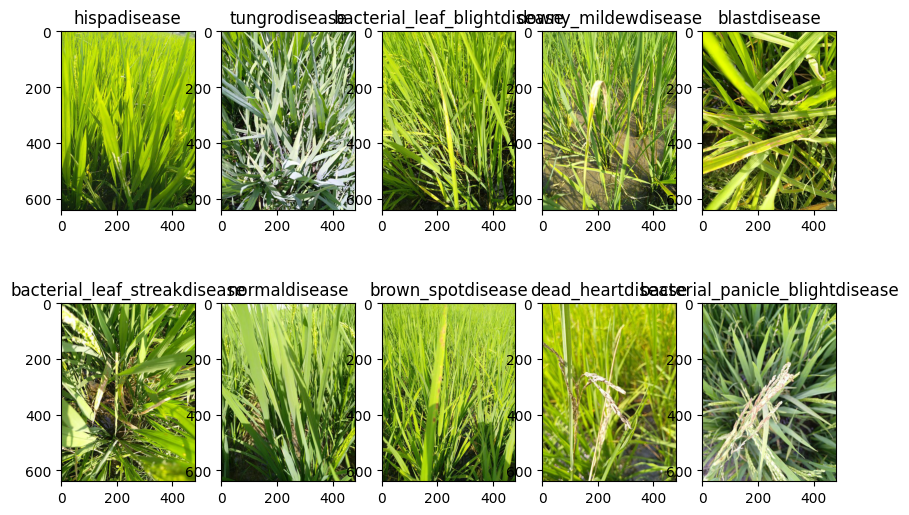

In [10]:
images = ['D:/python_for_data_science/paddy_rice/resources/train_images/hispa/106590.jpg',\
          'D:/python_for_data_science/paddy_rice/resources/train_images/tungro/109629.jpg',\
          'D:/python_for_data_science/paddy_rice/resources/train_images/bacterial_leaf_blight/109372.jpg',\
          'D:/python_for_data_science/paddy_rice/resources/train_images/downy_mildew/102350.jpg',\
          'D:/python_for_data_science/paddy_rice/resources/train_images/blast/110243.jpg',\
          'D:/python_for_data_science/paddy_rice/resources/train_images/bacterial_leaf_streak/101104.jpg',\
          'D:/python_for_data_science/paddy_rice/resources/train_images/normal/109760.jpg',\
          'D:/python_for_data_science/paddy_rice/resources/train_images/brown_spot/104675.jpg',\
          'D:/python_for_data_science/paddy_rice/resources/train_images/dead_heart/105159.jpg',\
          'D:/python_for_data_science/paddy_rice/resources/train_images/bacterial_panicle_blight/101351.jpg',\
]

disease_types = ['hispa', 'tungro', 'bacterial_leaf_blight', 'downy_mildew', 'blast', 'bacterial_leaf_streak', 'normal', 'brown_spot', 'dead_heart', 'bacterial_panicle_blight']

disease_types = [disease_types + 'disease' for disease_types in disease_types]
plt.figure(figsize=(10, 10))
columns = 5
for i, image_loc in enumerate(images):
    plt.subplot(len(images)// columns + 1, columns, i + 1)
    image = plt.imread(image_loc)
    plt.title(disease_types[i])
    plt.imshow(image)



In [11]:
data.head()

,image_id,label,variety,age
0,100330.jpg,bacterial_leaf_blight,ADT45,45
1,100365.jpg,bacterial_leaf_blight,ADT45,45
2,100382.jpg,bacterial_leaf_blight,ADT45,45
3,100632.jpg,bacterial_leaf_blight,ADT45,45
4,101918.jpg,bacterial_leaf_blight,ADT45,45


In [12]:
# encoding the label and variety columns
from sklearn.preprocessing import LabelEncoder

data['label'] = LabelEncoder().fit_transform(data['label'])
data['variety'] = LabelEncoder().fit_transform(data['variety'])

data.head()

,image_id,label,variety,age
0,100330.jpg,0,0,45
1,100365.jpg,0,0,45
2,100382.jpg,0,0,45
3,100632.jpg,0,0,45
4,101918.jpg,0,0,45


In [13]:
# define parameter 
batch_size = 32
img_height = 224
img_width = 224

In [14]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    path,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size,
)

Found 10407 files belonging to 10 classes.
Using 8326 files for training.


In [15]:
val_ds = tf.keras.utils.image_dataset_from_directory(
    path,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size,
    label_mode="categorical",
)

Found 10407 files belonging to 10 classes.
Using 2081 files for validation.


In [16]:
class_name = train_ds.class_names
class_name

['bacterial_leaf_blight',
 'bacterial_leaf_streak',
 'bacterial_panicle_blight',
 'blast',
 'brown_spot',
 'dead_heart',
 'downy_mildew',
 'hispa',
 'normal',
 'tungro']

In [17]:
for images, labels in train_ds.take(1):
    print(images.shape)
    print(labels.shape)
    break

(32, 224, 224, 3)
(32,)


In [18]:
normalizatiom_layer = tf.keras.layers.Rescaling(1./255)

In [19]:
# check the normalized data
normalized_ds = train_ds.map(lambda x, y: (normalizatiom_layer(x), y))

images, labels = next(iter(normalized_ds))
first_image = images[0]
# notice the pixel values are between 0 and 1
print(np.min(first_image), np.max(first_image))

0.0 1.0


In [20]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [21]:
num_classes = len(class_name)
num_classes

10

In [23]:


# CNN modle building 
model = tf.keras.Sequential([
    tf.keras.layers.Rescaling(1./255),
    tf.keras.layers.Conv2D(32,  3, activation='relu'), # convolutional layer
    tf.keras.layers.MaxPooling2D(), # pooling layer
    tf.keras.layers.Conv2D(64,  3, activation='relu'), # convolutional layer
    tf.keras.layers.MaxPooling2D(), # pooling layer
    tf.keras.layers.Conv2D(64,  3, activation='relu'),
    tf.keras.layers.MaxPooling2D(), # pooling layer
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dropout(0.25),
    tf.keras.layers.Dense(128, activation='relu'), # flatten layer
    tf.keras.layers.Dense(num_classes, activation='softmax') # output layer # why we did add 10?

])
# compile the model
model.compile(optimizer='adam', loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True), metrics=['accuracy'])

In [27]:
%%time 
import warnings
from tensorflow.keras.callbacks import EarlyStopping
# remove warnings
warnings.filterwarnings('ignore')
# define the early stopping callback
early_stopping = EarlyStopping(patience=2)
# fit the model 
history = model.fit(train_ds, validation_data=val_ds, epochs=1, callbacks=[early_stopping])

# evaluate the model
loss, accuracy = model.evaluate(val_ds)
# plotting the training and testing loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

# plotting the training and testing accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

261/261 [==============================] - ETA: 0s - loss: 1.3814 - accuracy: 0.5398

ValueError: in user code:

    File "c:\Users\nasik\miniconda3\envs\tf_gpu\lib\site-packages\keras\engine\training.py", line 1727, in test_function  *
        return step_function(self, iterator)
    File "c:\Users\nasik\miniconda3\envs\tf_gpu\lib\site-packages\keras\engine\training.py", line 1713, in step_function  **
        outputs = model.distribute_strategy.run(run_step, args=(data,))
    File "c:\Users\nasik\miniconda3\envs\tf_gpu\lib\site-packages\keras\engine\training.py", line 1701, in run_step  **
        outputs = model.test_step(data)
    File "c:\Users\nasik\miniconda3\envs\tf_gpu\lib\site-packages\keras\engine\training.py", line 1668, in test_step
        return self.compute_metrics(x, y, y_pred, sample_weight)
    File "c:\Users\nasik\miniconda3\envs\tf_gpu\lib\site-packages\keras\engine\training.py", line 1092, in compute_metrics
        self.compiled_metrics.update_state(y, y_pred, sample_weight)
    File "c:\Users\nasik\miniconda3\envs\tf_gpu\lib\site-packages\keras\e

## Observation 

1. We have 10 classes of rice disease.
2. We have 10407 images for each class. 
3. We have 10 varieties of rice.
4. We have rice plant age from 45 to 85 days.
5. ADT45 is the most common variety inside the training data.